# ResNet-18 (Augmented v2 — Dropout + AdamW + TTA)

**Objective**: Further refine the ResNet-18 pipeline by introducing modern optimization and inference techniques. This experiment switches to **AdamW** for better weight decay interaction, adds **Dropout** to the classifier head to force feature redundancy, and implements **Test-Time Augmentation (TTA)** to stabilize predictions at inference.

**Architecture Changes**:
| Component | Previous iteration (Aug v1) | This iteration (Aug v2) |
|---|---|---|
| Optimizer | Adam | AdamW |
| Dropout | 0 | 0.4 before FC |
| Inference | Single Pass | TTA (8-pass average) |
| Augmentation | Strong | Strong |
| Weight decay | 1e-4 | 1e-4 (decoupled) |
| Epochs | 20 | 20 |

**Hypothesis**: AdamW and Dropout should further reduce overfitting compared to Aug v1. TTA is expected to provide a "free" boost to AUC and F2 by averaging out noise in individual augmented passes, helping the model make more confident predictions on borderline melanoma cases.

## Import libraries, set seed, and choose device

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from PIL import Image
from sklearn.metrics import fbeta_score

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
DROPOUT = 0.4
model = get_resnet(num_classes=1, freeze_backbone=False, dropout=DROPOUT).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 0.0
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 11,177,025 / 11,177,025
L1 lambda: 0.0 | L2 lambda: 0.0 | Dropout: 0.4


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/resnet_augmented_v2_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/20]
  Train | Loss: 0.9342, Bal Acc: 0.7359, Recall: 0.7845, F2: 0.5357, AUC: 0.8151
  Val   | Loss: 0.8461, Bal Acc: 0.7737, Recall: 0.7839, F2: 0.5960, AUC: 0.8576
  -> Saved best model (val AUC: 0.8576)


Epoch [2/20]
  Train | Loss: 0.7966, Bal Acc: 0.7737, Recall: 0.8210, F2: 0.5831, AUC: 0.8643
  Val   | Loss: 0.7895, Bal Acc: 0.7849, Recall: 0.9025, F2: 0.6079, AUC: 0.8855
  -> Saved best model (val AUC: 0.8855)


Epoch [3/20]
  Train | Loss: 0.7718, Bal Acc: 0.7893, Recall: 0.8221, F2: 0.6047, AUC: 0.8766
  Val   | Loss: 0.7617, Bal Acc: 0.8045, Recall: 0.7797, F2: 0.6420, AUC: 0.8904
  -> Saved best model (val AUC: 0.8904)


Epoch [4/20]
  Train | Loss: 0.7285, Bal Acc: 0.8070, Recall: 0.8540, F2: 0.6279, AUC: 0.8884
  Val   | Loss: 0.7506, Bal Acc: 0.7870, Recall: 0.8771, F2: 0.6113, AUC: 0.8908
  -> Saved best model (val AUC: 0.8908)


Epoch [5/20]
  Train | Loss: 0.6987, Bal Acc: 0.8132, Recall: 0.8529, F2: 0.6374, AUC: 0.8973
  Val   | Loss: 0.8562, Bal Acc: 0.7998, Recall: 0.7797, F2: 0.6345, AUC: 0.8868


...

Epoch [16/20]
  Train | Loss: 0.3673, Bal Acc: 0.9087, Recall: 0.9202, F2: 0.7996, AUC: 0.9729
  Val   | Loss: 0.9193, Bal Acc: 0.7992, Recall: 0.7203, F2: 0.6381, AUC: 0.9080
  -> Saved best model (val AUC: 0.9080)


Epoch [17/20]
  Train | Loss: 0.3439, Bal Acc: 0.9218, Recall: 0.9418, F2: 0.8206, AUC: 0.9764
  Val   | Loss: 0.9123, Bal Acc: 0.7983, Recall: 0.7331, F2: 0.6356, AUC: 0.9078


Epoch [18/20]
  Train | Loss: 0.3228, Bal Acc: 0.9284, Recall: 0.9475, F2: 0.8335, AUC: 0.9792
  Val   | Loss: 1.0023, Bal Acc: 0.7904, Recall: 0.7161, F2: 0.6236, AUC: 0.9036


Epoch [19/20]
  Train | Loss: 0.3067, Bal Acc: 0.9333, Recall: 0.9555, F2: 0.8417, AUC: 0.9810
  Val   | Loss: 1.0002, Bal Acc: 0.7920, Recall: 0.6992, F2: 0.6274, AUC: 0.9081
  -> Saved best model (val AUC: 0.9081)


Epoch [20/20]
  Train | Loss: 0.3001, Bal Acc: 0.9346, Recall: 0.9567, F2: 0.8442, AUC: 0.9819
  Val   | Loss: 1.0282, Bal Acc: 0.7899, Recall: 0.6949, F2: 0.6240, AUC: 0.9071


## Plot Train and Validation Curves

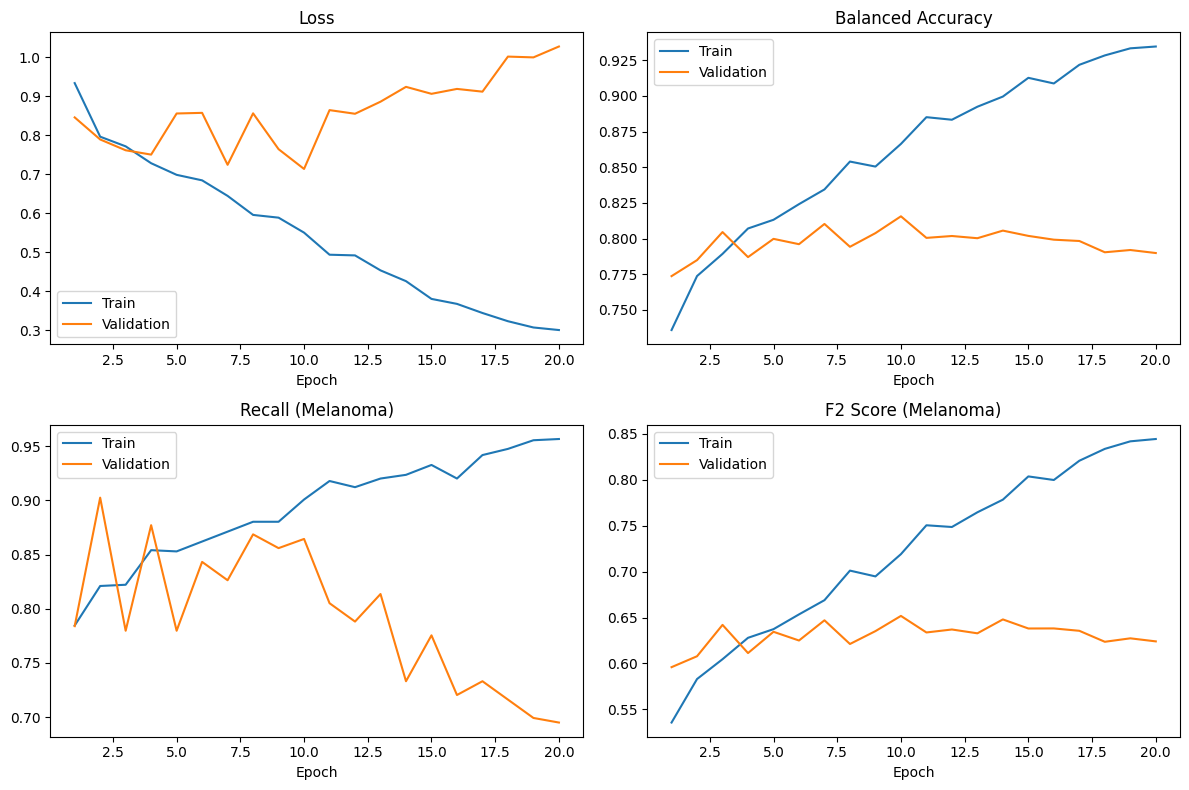

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet_augmented_v2_best.pth'), map_location=device))
model.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tta_transforms = [
    transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(90, 90)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(180, 180)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(270, 270)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.ColorJitter(brightness=0.1, contrast=0.1), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

def tta_predict(model, dataset, device, tta_transforms):
    all_probs = []
    all_labels = []
    for idx in range(len(dataset)):
        image_id = dataset.data.iloc[idx]['image_id']
        label = int(dataset.data.iloc[idx]['label'])
        img = Image.open(dataset.image_dir / (image_id + '.jpg')).convert('RGB')
        preds = []
        with torch.no_grad():
            for t in tta_transforms:
                tensor = t(img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor)).item()
                preds.append(prob)
        all_probs.append(np.mean(preds))
        all_labels.append(label)
    return np.array(all_probs), np.array(all_labels)

print("Running TTA on validation set...")
val_probs, val_labels = tta_predict(model, val_loader.dataset, device, tta_transforms)

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Running TTA on validation set...
Best threshold: 0.19 | Val F2: 0.6618


## Test Set Evaluation

In [7]:
from src.utils import evaluate_model
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

print("Running TTA on test set...")
test_probs, test_labels = tta_predict(model, test_loader.dataset, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f"Threshold:          {best_threshold:.2f}")
print(f"AUC-ROC:            {auc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"F2 Score:           {f2:.4f}")
print()
print(classification_report(test_labels, all_preds, target_names=["Non-Melanoma", "Melanoma"], digits=4))

Running TTA on test set...
Threshold:          0.19
AUC-ROC:            0.9229
Balanced Accuracy:  0.8387
F2 Score:           0.6827

              precision    recall  f1-score   support

Non-Melanoma     0.9793    0.8119    0.8878      1340
    Melanoma     0.3700    0.8655    0.5184       171

    accuracy                         0.8180      1511
   macro avg     0.6746    0.8387    0.7031      1511
weighted avg     0.9103    0.8180    0.8460      1511

